In [1]:
# Ignore all other GPUs except this one
!export CUDA_VISIBLE_DEVICES=0

In [2]:
import numpy as np         
import matplotlib.pyplot as plt     
from matplotlib.animation import FuncAnimation          
import torch      
import torch.nn as nn    
import torch.optim as optim 
from torch.optim.lr_scheduler import ReduceLROnPlateau 
from torch.utils.data import TensorDataset, DataLoader        
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split 
import time      
from scipy.ndimage import uniform_filter1d    
import pandas as pd
import pickle 
import os
from IPython.display import HTML

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

Assume we have $\phi$ and $n_e$ measurements.\
Want to reconstruct $\bold{E}$ and $\bold{v_e}$

In [4]:
##Assume we are using Atomic Natural Units##

#Define fundamental constants 
c = 1 
q_e = 1
ep_0 = 1/(4*np.pi)
k_B=1
T_e = 1e-3 #1 kev
m_e = .511 #Mev/c^2 

#Define amplitudes
n0=1 
phi1=1

#Define our limits and fundamental plasma values (plasma freq, debye length)
omega_p = np.sqrt((q_e**2)*n0/(ep_0*m_e)) #plasma frequency defined by amplitude electron density 
v_th = np.sqrt(k_B*T_e/m_e) #thermal velocity 
gamma = 3

#Setting our limits of propagation and our frequencies
x_min = -5
x_max = 5
Lx = 10 #computer being stupid....

k=2*np.pi/Lx

#PDEs using plane wave approximation must satisfy these quantities 
omega = np.sqrt(omega_p**2 + gamma*(k**2)*(v_th**2)) #dispersion relation for langmuir waves
n1 = (ep_0/q_e)*(k**2)*phi1
v1=(omega/k)*(n1/n0)


period = 2*np.pi/omega #period of the waves 
tau = 5 * period #define how long the wave will propagate for 

In [5]:
def analytical_solution(x, t):
    
    phi = phi1*np.sin(k*x - omega*t)
    Ex = -1*k*phi1*np.sin(k*x-omega*t)
    ne = n0+n1*np.sin(k*x - omega*t)
    ne1 = ne-n0
    ve = (omega/k)*(ne1/n0)
    
    return phi,Ex,ne,ve

def generate_data(nx, nt, Lx, tau):

    x = np.linspace(0, Lx, nx)
    t = np.linspace(0, tau, nt)

    x_arr, t_arr =  np.meshgrid(x,t, indexing='xy')

    phi, Ex, ne, ve = analytical_solution(x_arr,t_arr)
    
    return x_arr.flatten(), t_arr.flatten(), phi.flatten(), Ex.flatten(), ne.flatten(), ve.flatten()

def sparse_measurements(x, t, phi, ne, num_samples):

    indices = np.random.choice(x.shape[0], num_samples, replace=False)

    return x[indices], t[indices], phi[indices], ne[indices]

def collocation_points(nx, nt, Lx, tau):

    x = np.linspace(0, Lx, nx)
    t = np.linspace(0, tau, nt)

    x_coll, t_coll = np.meshgrid(x, t, indexing='xy')

    return x_coll.flatten(), t_coll.flatten()

In [6]:
Nx, Nt = 100, 100

X_flat, T_flat, Phi_flat, Ex_flat, ne_flat, ve_flat= generate_data(Nx, Nt, Lx, tau)

x_sparse, t_sparse, phi_sparse, ne_sparse = sparse_measurements(X_flat, T_flat, \
                                                                Phi_flat, ne_flat, \
                                                                num_samples=200)
x_coll, t_coll = collocation_points(Nx,Nt,Lx,tau)

In [7]:
class Sin(nn.Module):

    def __init__(self):
        super(Sin, self).__init__()

    def forward(self, x):
        return torch.sin(x)
    
class Tanh(nn.Module): 
    
    def __init__(self): 
        super(Tanh,self).__init__()
    
    def forward(self, x): 
        return torch.tanh(x)
    
class Swish(nn.Module): 
    
    def __init__(self): 
        super(Swish, self).__init__()
    
    def forward(self, x): 
        return (x/(1+torch.exp(x)))
    
class Sigmoid(nn.Module): 
    
    def __inint__(self): 
        super(Sigmoid, self).__init__init()
    def forward(self, x): 
        return (1/(1+torch.exp(x)))


class PINN(nn.Module):
    
    def __init__(self, Lx, tau): 
        
        super(PINN, self).__init__()
        
        self.net = nn.Sequential(
            nn.Linear(2,100),
            Sin(), 
            nn.Linear(100,100),
            Sin(),
            nn.Linear(100,100),
            Sin(),
            nn.Linear(100,100),
            Sin(),
            nn.Linear(100,4)
        )

        self.Lx = Lx
        self.tau = tau
        
    def forward(self, x,  t):
        
        # This operation normalizes the input coordinates to be contained within the range [-1, 1].
        
        x = 2.0*(x / self.Lx) - 1
        t = 2.0*(t / self.tau) - 1
        
        inputs = torch.cat([x,t], dim = 1)
        
        return self.net(inputs)

We are assuming an electrostatic oscillation\
Equation Constraints:\
(1) $\frac{\partial^2 n_{e1}}{\partial t^{2}}+\Omega_{pe}^2 n_{e1} - \gamma v_{Te}^{2}\nabla^{2}n_{e1}=0$\
(2) $\frac{\partial n_{e}}{\partial t} + \nabla \cdot (n_e \bold{v_e})= 0$\
(3) $\nabla^{2}\phi + \frac{e}{\epsilon_0}(n_e - n_0)$\
(4) $\bold{E} + \nabla\phi = 0$

where (1)density continuity, (2)momentum continuity, (3)Gauss's Law, (4)Electric potential and field relation

In [8]:
def pinn_loss(model, x_sparse, t_sparse, phi_sparse, ne_sparse, means, stds, x_col, t_col):
    
    # Data loss measuring loss of Bdots
    
    sparse_preds = model(x_sparse, t_sparse)
    
    phi_sparse_preds = sparse_preds[:,0].reshape(-1,1)#potential measurements
    phi_sparse_preds = (phi_sparse_preds - means)/stds
    phi_loss = torch.mean(torch.square(phi_sparse_preds - phi_sparse))
    ne_sparse_preds = sparse_preds[:,2].reshape(-1,1)#density measurements
    ne_sparse_preds = (phi_sparse_preds - means)/stds
    ne_loss = torch.mean(torch.square(ne_sparse_preds-ne_sparse))    
    loss_data = phi_loss+ne_loss
    
    
    #Physics loss from collocation points
    col_preds = model(x_col, t_col) * stds + means
    phi = col_preds[:,0]
    E = col_preds[:,1]
    ne = col_preds[:,2]
    ve = col_preds[:,3]
    grad_P = gamma*ne*k_B*T_e
    
    
    E = E.reshape(-1,1)
    phi = phi.reshape(-1,1)
    
    #time derivatives and gradients
    phi_x = torch.autograd.grad(phi, x_col, grad_outputs=torch.ones_like(phi), create_graph=True, retain_graph=True)[0]
    phi_xx = torch.autograd.grad(phi_x, x_col, grad_outputs=torch.ones_like(phi), create_graph=True, retain_graph=True)[0]
    ne_t = torch.autograd.grad(ne, t_col, grad_outputs=torch.ones_like(ne), create_graph=True, retain_graph=True)[0]
    ne_tt = torch.autograd.grad(ne_t, t_col, grad_outputs=torch.ones_like(ne_t), create_graph=True, retain_graph=True)[0]
    ne_x = torch.autograd.grad(ne, x_col, grad_outputs=torch.ones_like(ne), create_graph=True, retain_graph=True)[0]
    ne_xx = torch.autograd.grad(ne_x, x_col, grad_outputs=torch.ones_like(ne_x), create_graph=True, retain_graph=True)[0]
    ve_x = torch.autograd.grad(ve, x_col, grad_outputs=torch.ones_like(ve), create_graph=True, retain_graph=True)[0]
    
    
    #physics constrain loss
    momentum = ne_tt + (omega_p**2)*(ne-n0) - gamma*(v_th**2)*ne_xx
    momentum = torch.mean(momentum**2)
    
    dens_cont = ne_t + (ne_x)*ve + ne*(ve_x)
    dens_cont = torch.mean(dens_cont**2)
    
    poisson = phi_xx + (q_e/ep_0)*(ne-n0)
    poisson = torch.mean(poisson**2)
    
    phi_E = E + phi_x
    phi_E = torch.mean(phi_E**2)
    
    loss_physics = momentum + dens_cont + poisson + phi_E 

    return loss_data, loss_physics

In [9]:
# Convert data to PyTorch tensors
x_sparse = torch.tensor(x_sparse.flatten(), dtype=torch.float32, requires_grad=True).reshape(-1,1)
t_sparse = torch.tensor(t_sparse.flatten(), dtype=torch.float32, requires_grad=True).reshape(-1,1)
phi_sparse = torch.tensor(phi_sparse.flatten(), dtype=torch.float32, requires_grad=True).reshape(-1,1)
ne_sparse = torch.tensor(ne_sparse.flatten(), dtype=torch.float32, requires_grad=True).reshape(-1,1)


x_coll = torch.tensor(x_coll.flatten(), dtype=torch.float32).reshape(-1,1).requires_grad_()
t_coll = torch.tensor(t_coll.flatten(), dtype=torch.float32).reshape(-1,1).requires_grad_()

means = torch.stack((torch.mean(phi_sparse, 0).detach(), torch.mean(phi_sparse, 0).detach(), torch.mean(ne_sparse, 0).detach(), torch.mean(phi_sparse, 0).detach()), dim=1)
stds = torch.stack((torch.std(phi_sparse, 0).detach(), torch.std(phi_sparse, 0).detach(), torch.mean(ne_sparse, 0).detach(), torch.mean(phi_sparse, 0).detach()), dim=1)


means[:,0] = 0.0
stds[:,0] = 1.0
means[:,1] = 0.0
stds[:,1] = 1.0
means[:,2] = 0.0
stds[:,2] = 1.0
means[:,3] = 0.0
stds[:,3] = 1.0



print('Means = ', means)
print('Stds = ', stds)

# Create DataLoaders
batch_size = int(x_coll.size()[0] // 50)

Means =  tensor([[0., 0., 0., 0.]])
Stds =  tensor([[1., 1., 1., 1.]])


In [10]:
start_time = time.time()
model = PINN(Lx, tau)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=50, verbose=True)

num_epochs = 10000
n_batches = 50


hist = {
    'data_loss': [],
    'physics_loss': [],
    'total_loss': [],
    'learning_rate': []
}

for epoch in range(num_epochs):
    
    epoch_sm_loss = 0
    epoch_phys_loss = 0
    epoch_total_loss = 0
    num_batches = 0

    for i in range(n_batches):

        n_coll = x_coll.shape[0]
        i_idxs = np.random.choice(n_coll, size = n_coll, replace = False)

        x_col_batch = x_coll[i_idxs[i::n_batches],:]
        t_col_batch = t_coll[i_idxs[i::n_batches],:]
        
        optimizer.zero_grad()
        
        sm_loss, phys_loss = pinn_loss(model, x_sparse, t_sparse, phi_sparse, ne_sparse, means, stds, x_col_batch, t_col_batch)
     
        total_loss = sm_loss + phys_loss
        
        total_loss.backward()
        optimizer.step()

        epoch_sm_loss += sm_loss.item()
        epoch_phys_loss += phys_loss.item()
        epoch_total_loss += total_loss.item()
        
        num_batches += 1

    # Calculate average losses for the epoch
    avg_sm_loss = epoch_sm_loss / num_batches
    avg_phys_loss = epoch_phys_loss / num_batches
    avg_total_loss = epoch_total_loss / num_batches

    # Step the scheduler
    scheduler.step(avg_total_loss)
    
    # Record history
    hist['data_loss'].append(avg_sm_loss)
    hist['physics_loss'].append(avg_phys_loss)
    hist['total_loss'].append(avg_total_loss)
    hist['learning_rate'].append(optimizer.param_groups[0]['lr'])
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Total Loss: {avg_total_loss:.4f}, "
              f"Sample Measurement Loss: {avg_sm_loss:.4f}, Physics Loss: {avg_phys_loss:.4f}, "
              f"LR: {optimizer.param_groups[0]['lr']:.6f}")
end_time = time.time() 
print("--- %s mins ---" % str(round((end_time-start_time)/60,2)))

/home/aleotz/.conda/envs/pinn_recon/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 10/10000, Total Loss: 0.8850, Sample Measurement Loss: 0.8552, Physics Loss: 0.0298, LR: 0.001000
Epoch 20/10000, Total Loss: 0.8559, Sample Measurement Loss: 0.8542, Physics Loss: 0.0017, LR: 0.001000
Epoch 30/10000, Total Loss: 0.8546, Sample Measurement Loss: 0.8535, Physics Loss: 0.0011, LR: 0.001000
Epoch 40/10000, Total Loss: 0.8540, Sample Measurement Loss: 0.8529, Physics Loss: 0.0011, LR: 0.001000
Epoch 50/10000, Total Loss: 0.8530, Sample Measurement Loss: 0.8523, Physics Loss: 0.0007, LR: 0.001000
Epoch 60/10000, Total Loss: 0.8523, Sample Measurement Loss: 0.8515, Physics Loss: 0.0008, LR: 0.001000
Epoch 70/10000, Total Loss: 0.8538, Sample Measurement Loss: 0.8503, Physics Loss: 0.0035, LR: 0.001000
Epoch 80/10000, Total Loss: 0.8489, Sample Measurement Loss: 0.8483, Physics Loss: 0.0006, LR: 0.001000
Epoch 90/10000, Total Loss: 0.8499, Sample Measurement Loss: 0.8471, Physics Loss: 0.0028, LR: 0.001000
Epoch 100/10000, Total Loss: 0.8498, Sample Measurement Loss: 0.

KeyboardInterrupt: 

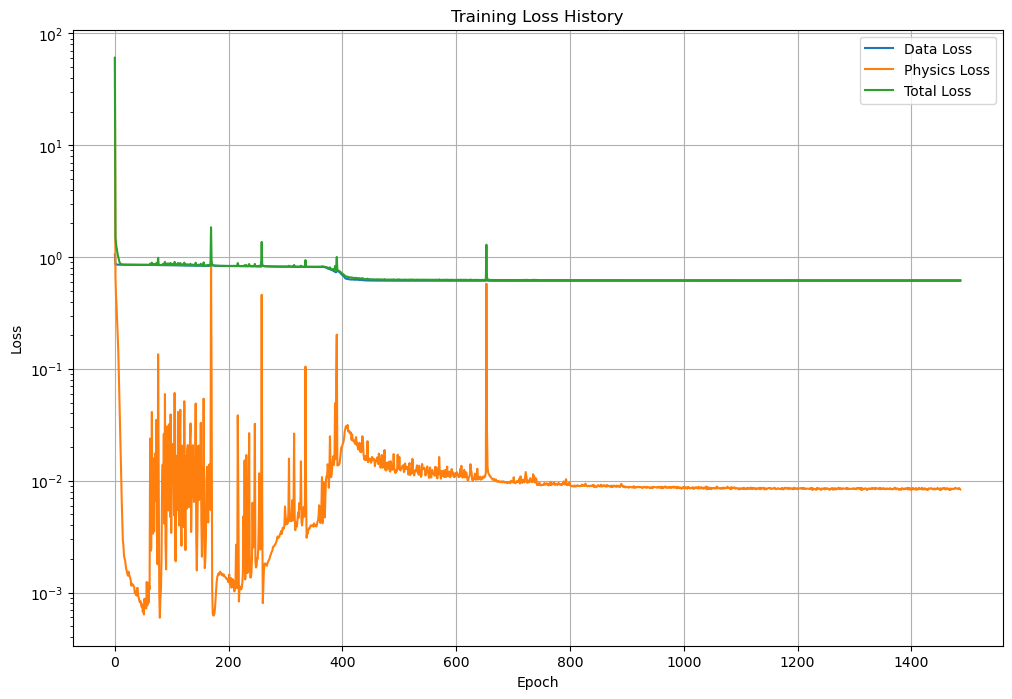

In [11]:
# Plot the loss history
plt.figure(figsize=(12, 8))
plt.semilogy(hist['data_loss'], label='Data Loss')
plt.semilogy(hist['physics_loss'], label='Physics Loss')
plt.semilogy(hist['total_loss'], label='Total Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss History')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
x_sparse = x_sparse.detach().cpu().numpy()
t_sparse = t_sparse.detach().cpu().numpy()

<>:25: SyntaxWarning: invalid escape sequence '\p'
<>:27: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\o'
<>:33: SyntaxWarning: invalid escape sequence '\p'
<>:35: SyntaxWarning: invalid escape sequence '\l'
<>:36: SyntaxWarning: invalid escape sequence '\o'
<>:41: SyntaxWarning: invalid escape sequence '\p'
<>:43: SyntaxWarning: invalid escape sequence '\l'
<>:44: SyntaxWarning: invalid escape sequence '\o'
<>:45: SyntaxWarning: invalid escape sequence '\p'
<>:49: SyntaxWarning: invalid escape sequence '\p'
<>:51: SyntaxWarning: invalid escape sequence '\l'
<>:52: SyntaxWarning: invalid escape sequence '\o'
<>:63: SyntaxWarning: invalid escape sequence '\p'
<>:65: SyntaxWarning: invalid escape sequence '\l'
<>:66: SyntaxWarning: invalid escape sequence '\o'
<>:71: SyntaxWarning: invalid escape sequence '\p'
<>:73: SyntaxWarning: invalid escape sequence '\l'
<>:74: SyntaxWarning: invalid escape sequence '\o'
<>:79: SyntaxWarning: invalid e

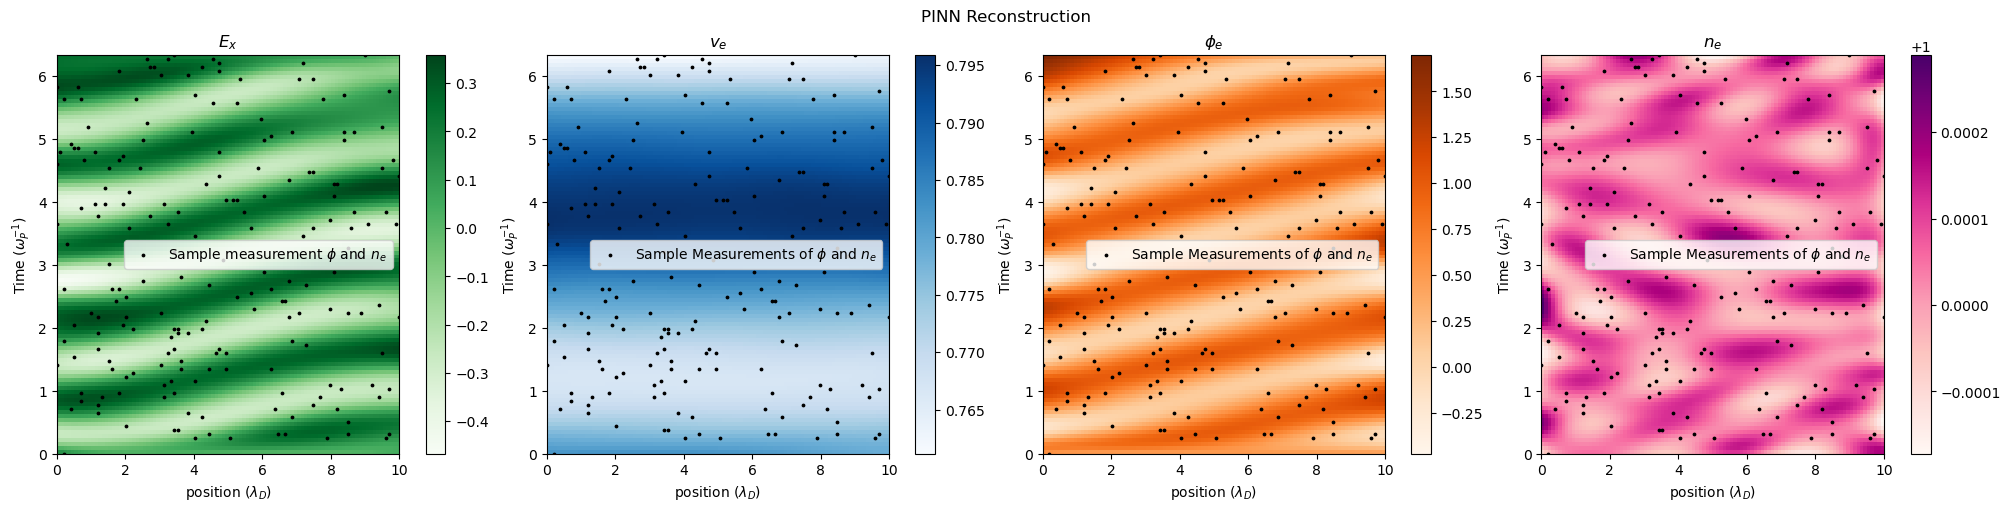

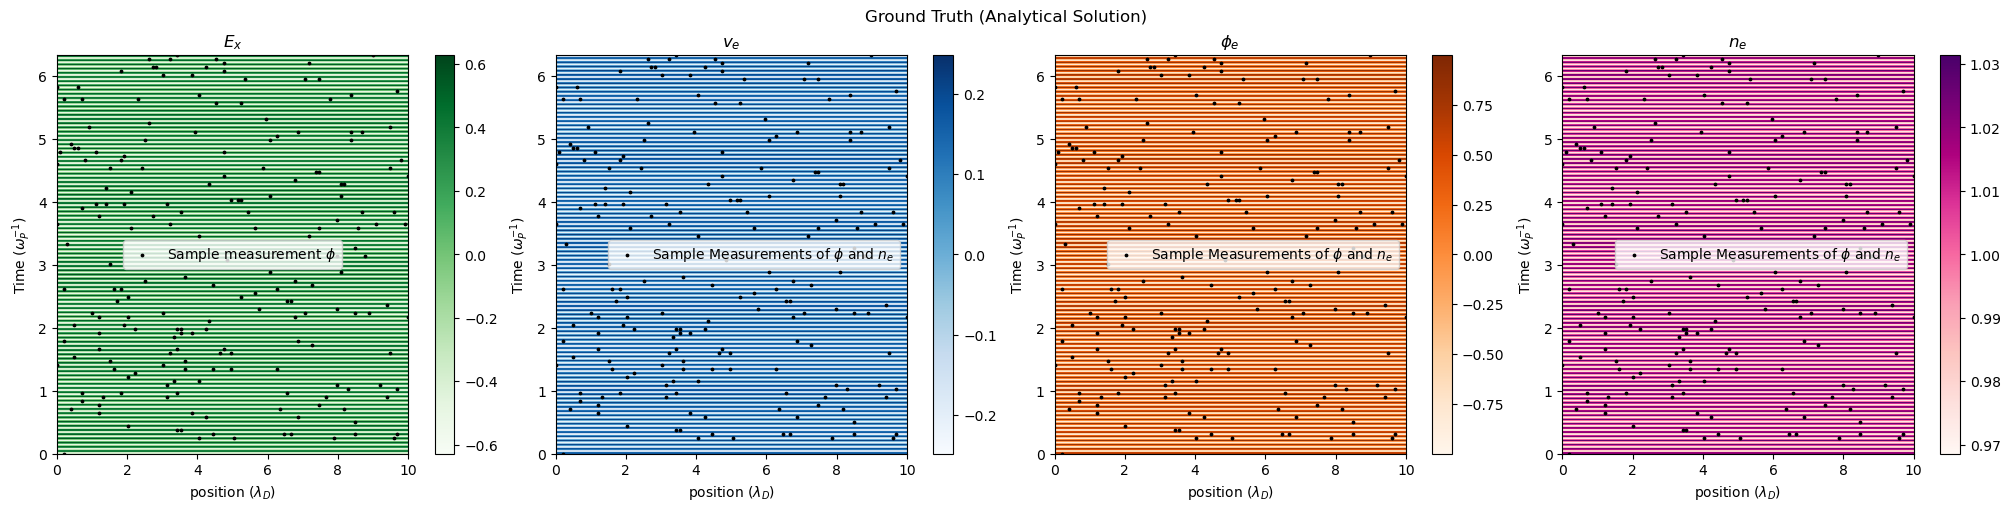

In [13]:
X_reconstruct = torch.tensor(X_flat, requires_grad=False, dtype=torch.float32).reshape(-1,1)
T_reconstruct = torch.tensor(T_flat, requires_grad=False, dtype=torch.float32).reshape(-1,1)



phi_true, E_true, n_true, v_true = analytical_solution(X_reconstruct, T_reconstruct)

phi_recon, E_recon, n_recon, v_recon= (model(X_reconstruct, T_reconstruct)*stds + means).T

phi_reconstructed = phi_recon.detach().cpu().numpy().reshape(100, 100)
E_reconstructed = E_recon.detach().cpu().numpy().reshape(100, 100)
n_reconstructed = n_recon.detach().cpu().numpy().reshape(100, 100)
v_reconstructed = v_recon.detach().cpu().numpy().reshape(100, 100)

phi_reconstructed = (phi_reconstructed)
E_reconstructed = (E_reconstructed)
n_reconstructed = (n_reconstructed)
v_reconstructed = (v_reconstructed)



ext = [0, Lx, 0, tau]

fig, (ax1,ax2,ax3,ax4) = plt.subplots(1,4, figsize=(20,5), constrained_layout=True)
ax1.scatter(x_sparse, t_sparse, color = 'black', s = 3, label = 'Sample measurement $\phi$ and $n_{e}$')
im1 = ax1.imshow(E_reconstructed, aspect = 'auto', cmap = 'Greens', origin = 'lower', extent = ext, alpha = 1, label = "PINN Reconstruction of $E$")
ax1.set_xlabel("position ($\lambda_{D}$)")
ax1.set_ylabel("Time ($\omega_{P}^{-1}$)")
ax1.set_title("$E_{x}$")
ax1.legend()
fig.colorbar(im1, ax=ax1,)

ax2.scatter(x_sparse, t_sparse, color = 'black', s = 3, label = 'Sample Measurements of $\phi$ and $n_{e}$')
im2 = ax2.imshow(v_reconstructed, aspect = 'auto', cmap = 'Blues', origin = 'lower', extent = ext, alpha = 1)
ax2.set_xlabel("position ($\lambda_{D}$)")
ax2.set_ylabel("Time ($\omega_{P}^{-1}$)")
ax2.set_title("$v_{e}$")
ax2.legend()
fig.colorbar(im2)

ax3.scatter(x_sparse, t_sparse, color = 'black', s = 3, label = 'Sample Measurements of $\phi$ and $n_{e}$')
im3 = ax3.imshow(phi_reconstructed, aspect = 'auto', cmap = 'Oranges', origin = 'lower', extent = ext, alpha = 1)
ax3.set_xlabel("position ($\lambda_{D}$)")
ax3.set_ylabel("Time ($\omega_{P}^{-1}$)")
ax3.set_title("$\phi_{e}$")
ax3.legend()
fig.colorbar(im3)

ax4.scatter(x_sparse, t_sparse, color = 'black', s = 3, label = 'Sample Measurements of $\phi$ and $n_{e}$')
im4 = ax4.imshow(n_reconstructed, aspect = 'auto', cmap = 'RdPu', origin = 'lower', extent = ext, alpha = 1)
ax4.set_xlabel("position ($\lambda_{D}$)")
ax4.set_ylabel("Time ($\omega_{P}^{-1}$)")
ax4.set_title("$n_{e}$")
ax4.legend()
fig.colorbar(im4)

plt.suptitle("PINN Reconstruction")
# plt.tight_layout()
plt.show()


fig, (ax5,ax6,ax7,ax8) = plt.subplots(1,4, figsize=(20,5), constrained_layout=True)
ax5.scatter(x_sparse, t_sparse, color = 'black', s = 3, label = 'Sample measurement $\phi$')
im5=ax5.imshow((E_true), aspect = 'auto', cmap='Greens', origin = 'lower', extent = ext, alpha = 1, label = "PINN Reconstruction of $E$")
ax5.set_xlabel("position ($\lambda_{D}$)")
ax5.set_ylabel("Time ($\omega_{P}^{-1}$)")
ax5.set_title("$E_{x}$")
ax5.legend()
fig.colorbar(im5)

ax6.scatter(x_sparse, t_sparse, color = 'black', s = 3, label = 'Sample Measurements of $\phi$ and $n_{e}$')
im6=ax6.imshow((v_true), aspect = 'auto', cmap = 'Blues', origin = 'lower', extent = ext, alpha = 1)
ax6.set_xlabel("position ($\lambda_{D}$)")
ax6.set_ylabel("Time ($\omega_{P}^{-1}$)")
ax6.set_title("$v_{e}$")
ax6.legend()
fig.colorbar(im6)

ax7.scatter(x_sparse, t_sparse, color = 'black', s = 3, label = 'Sample Measurements of $\phi$ and $n_{e}$')
im7=ax7.imshow((phi_true), aspect = 'auto', cmap = 'Oranges', origin = 'lower', extent = ext, alpha = 1)
ax7.set_xlabel("position ($\lambda_{D}$)")
ax7.set_ylabel("Time ($\omega_{P}^{-1}$)")
ax7.set_title("$\phi_{e}$")
ax7.legend()
fig.colorbar(im7)

ax8.scatter(x_sparse, t_sparse, color = 'black', s = 3, label = 'Sample Measurements of $\phi$ and $n_{e}$')
im8=ax8.imshow((n_true), aspect = 'auto', cmap = 'RdPu', origin = 'lower', extent = ext, alpha = 1)
ax8.set_xlabel("position ($\lambda_{D}$)")
ax8.set_ylabel("Time ($\omega_{P}^{-1}$)")
ax8.set_title("$n_{e}$")
ax8.legend()
fig.colorbar(im8)

plt.suptitle("Ground Truth (Analytical Solution)")
# plt.tight_layout()
plt.show()



<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:14: SyntaxWarning: invalid escape sequence '\o'
<>:19: SyntaxWarning: invalid escape sequence '\p'
<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:22: SyntaxWarning: invalid escape sequence '\o'
<>:27: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\l'
<>:30: SyntaxWarning: invalid escape sequence '\o'
<>:31: SyntaxWarning: invalid escape sequence '\p'
<>:35: SyntaxWarning: invalid escape sequence '\p'
<>:37: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\o'
<>:49: SyntaxWarning: invalid escape sequence '\p'
<>:51: SyntaxWarning: invalid escape sequence '\l'
<>:52: SyntaxWarning: invalid escape sequence '\o'
<>:57: SyntaxWarning: invalid escape sequence '\p'
<>:59: SyntaxWarning: invalid escape sequence '\l'
<>:60: SyntaxWarning: invalid escape sequence '\o'
<>:65: SyntaxWarning: invalid e

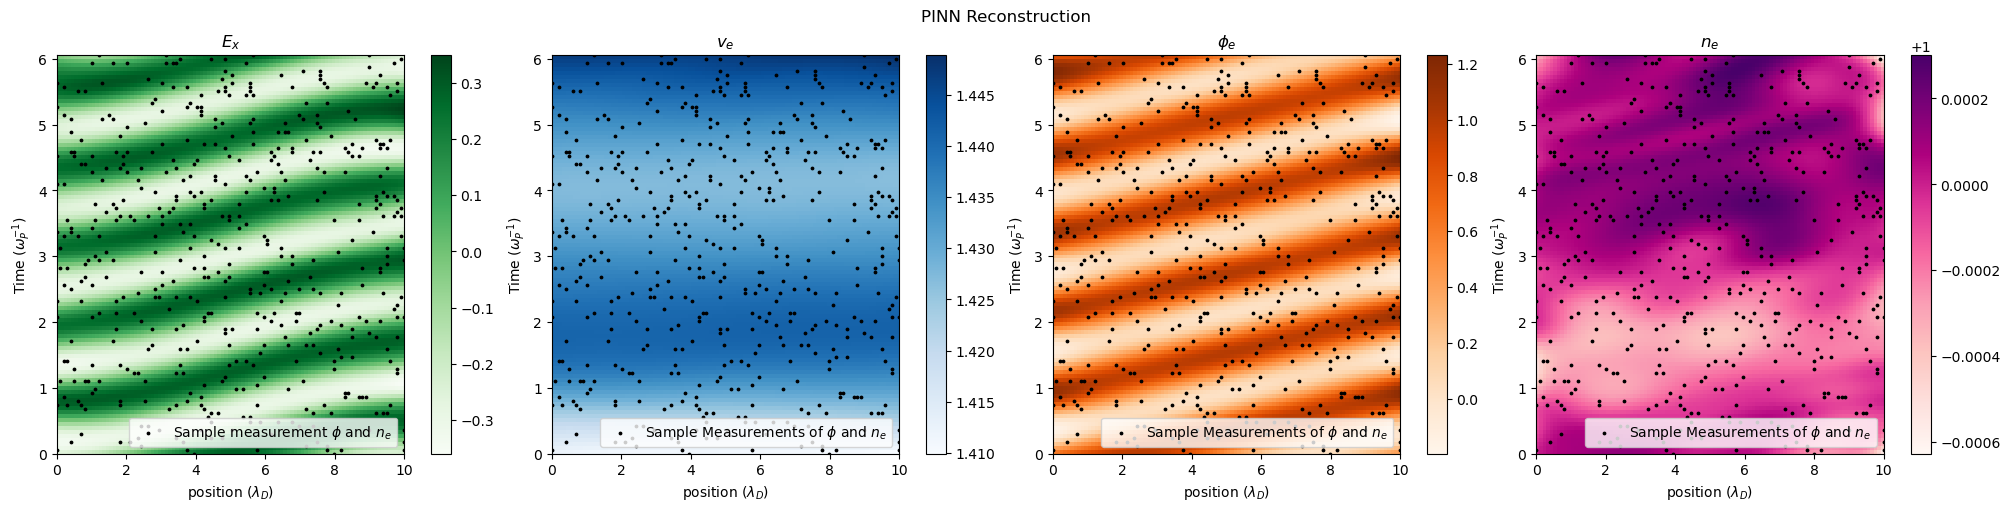

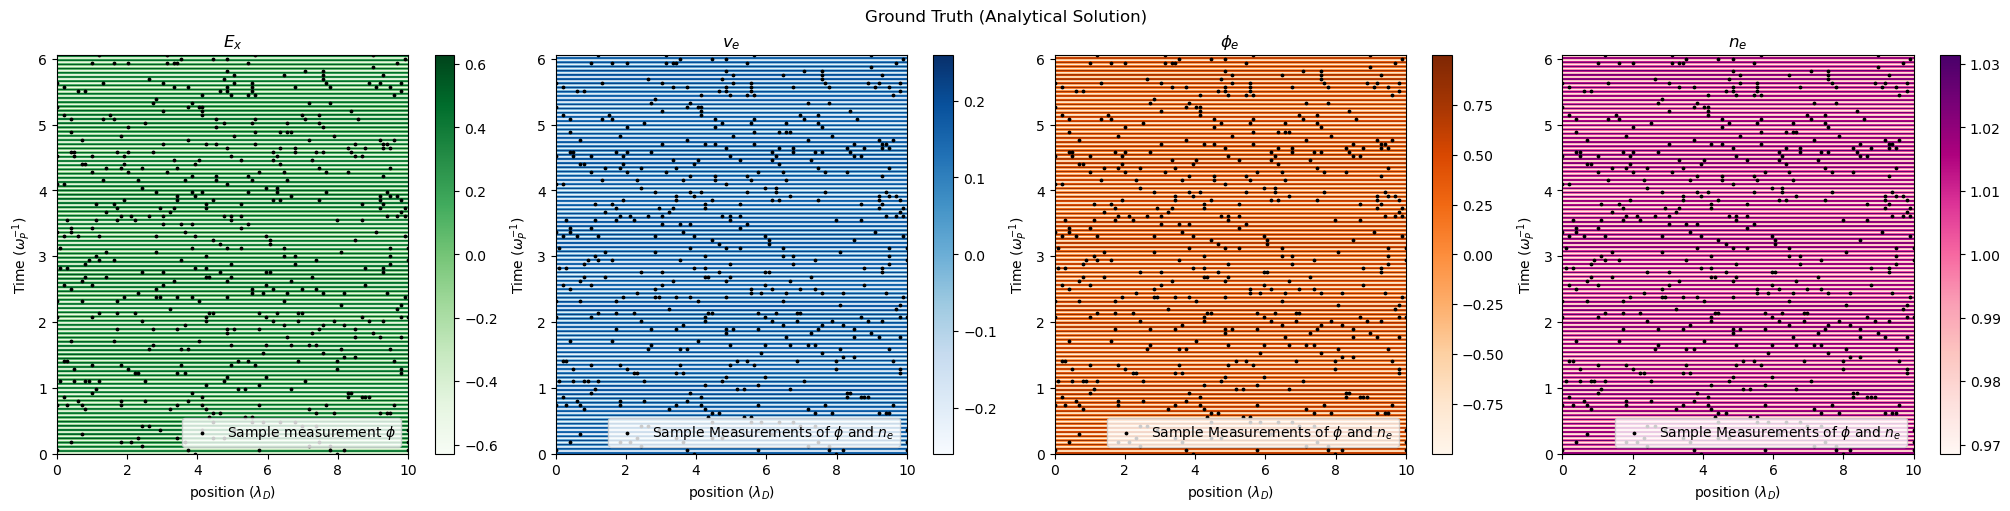

In [178]:
phi_reconstructed = np.real(phi_reconstructed)
E_reconstructed = np.real(E_reconstructed)
n_reconstructed = np.real(n_reconstructed)
v_reconstructed = np.real(v_reconstructed)



ext = [0, Lx, 0, tau]

fig, (ax1,ax2,ax3,ax4) = plt.subplots(1,4, figsize=(20,5), constrained_layout=True)
ax1.scatter(x_sparse, t_sparse, color = 'black', s = 3, label = 'Sample measurement $\phi$ and $n_{e}$')
im1 = ax1.imshow(E_reconstructed, aspect = 'auto', cmap = 'Greens', origin = 'lower', extent = ext, alpha = 1, label = "PINN Reconstruction of $E$")
ax1.set_xlabel("position ($\lambda_{D}$)")
ax1.set_ylabel("Time ($\omega_{P}^{-1}$)")
ax1.set_title("$E_{x}$")
ax1.legend()
fig.colorbar(im1, ax=ax1,)

ax2.scatter(x_sparse, t_sparse, color = 'black', s = 3, label = 'Sample Measurements of $\phi$ and $n_{e}$')
im2 = ax2.imshow(v_reconstructed, aspect = 'auto', cmap = 'Blues', origin = 'lower', extent = ext, alpha = 1)
ax2.set_xlabel("position ($\lambda_{D}$)")
ax2.set_ylabel("Time ($\omega_{P}^{-1}$)")
ax2.set_title("$v_{e}$")
ax2.legend()
fig.colorbar(im2)

ax3.scatter(x_sparse, t_sparse, color = 'black', s = 3, label = 'Sample Measurements of $\phi$ and $n_{e}$')
im3 = ax3.imshow(phi_reconstructed, aspect = 'auto', cmap = 'Oranges', origin = 'lower', extent = ext, alpha = 1)
ax3.set_xlabel("position ($\lambda_{D}$)")
ax3.set_ylabel("Time ($\omega_{P}^{-1}$)")
ax3.set_title("$\phi_{e}$")
ax3.legend()
fig.colorbar(im3)

ax4.scatter(x_sparse, t_sparse, color = 'black', s = 3, label = 'Sample Measurements of $\phi$ and $n_{e}$')
im4 = ax4.imshow(n_reconstructed, aspect = 'auto', cmap = 'RdPu', origin = 'lower', extent = ext, alpha = 1)
ax4.set_xlabel("position ($\lambda_{D}$)")
ax4.set_ylabel("Time ($\omega_{P}^{-1}$)")
ax4.set_title("$n_{e}$")
ax4.legend()
fig.colorbar(im4)

plt.suptitle("PINN Reconstruction")
# plt.tight_layout()
plt.show()


fig, (ax5,ax6,ax7,ax8) = plt.subplots(1,4, figsize=(20,5), constrained_layout=True)
ax5.scatter(x_sparse, t_sparse, color = 'black', s = 3, label = 'Sample measurement $\phi$')
im5=ax5.imshow(np.real(E_true), aspect = 'auto', cmap='Greens', origin = 'lower', extent = ext, alpha = 1, label = "PINN Reconstruction of $E$")
ax5.set_xlabel("position ($\lambda_{D}$)")
ax5.set_ylabel("Time ($\omega_{P}^{-1}$)")
ax5.set_title("$E_{x}$")
ax5.legend()
fig.colorbar(im5)

ax6.scatter(x_sparse, t_sparse, color = 'black', s = 3, label = 'Sample Measurements of $\phi$ and $n_{e}$')
im6=ax6.imshow(np.real(v_true), aspect = 'auto', cmap = 'Blues', origin = 'lower', extent = ext, alpha = 1)
ax6.set_xlabel("position ($\lambda_{D}$)")
ax6.set_ylabel("Time ($\omega_{P}^{-1}$)")
ax6.set_title("$v_{e}$")
ax6.legend()
fig.colorbar(im6)

ax7.scatter(x_sparse, t_sparse, color = 'black', s = 3, label = 'Sample Measurements of $\phi$ and $n_{e}$')
im7=ax7.imshow(np.real(phi_true), aspect = 'auto', cmap = 'Oranges', origin = 'lower', extent = ext, alpha = 1)
ax7.set_xlabel("position ($\lambda_{D}$)")
ax7.set_ylabel("Time ($\omega_{P}^{-1}$)")
ax7.set_title("$\phi_{e}$")
ax7.legend()
fig.colorbar(im7)

ax8.scatter(x_sparse, t_sparse, color = 'black', s = 3, label = 'Sample Measurements of $\phi$ and $n_{e}$')
im8=ax8.imshow(np.real(n_true), aspect = 'auto', cmap = 'RdPu', origin = 'lower', extent = ext, alpha = 1)
ax8.set_xlabel("position ($\lambda_{D}$)")
ax8.set_ylabel("Time ($\omega_{P}^{-1}$)")
ax8.set_title("$n_{e}$")
ax8.legend()
fig.colorbar(im8)

plt.suptitle("Ground Truth (Analytical Solution)")
# plt.tight_layout()
plt.show()



In [179]:
recons = [phi_recon, E_recon, n_recon, v_recon]
numpy_recons = [x.detach().cpu().numpy() for x in recons]

trues = [phi_true, E_true, n_true, v_true]
numpy_trues = [x.detach().cpu().numpy() for x in trues]

mses = []
for i in range(len(numpy_recons)):
    mse = np.mean((numpy_recons[i] - numpy_trues[i])**2)
    mses.append(mse)

print("phi_error: ", mses[0])
print("E_error: ", mses[1])
print("v_error: ", mses[2])
print("n_error: ", mses[3])

phi_error:  0.87479395
E_error:  0.23967804
v_error:  0.0004934588
n_error:  2.0876386


In [ ]:
import pickle 
with open("1D_langmuir_hist.pkl", 'wb') as f: 
    pickle.dump(hist, f)
with open('1D_langmuir_model.pkl', 'wb') as f: 
    pickle.dump(model, f)

In [ ]:
import pickle
with open("1D_langmuir_hist.pkl", 'rb') as f: 
    hist = pickle.load(f)
with open('1D_langmuir_model.pkl', 'rb') as f: 
    model = pickle.load(f)